# **Finding Missing Values**

Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.

## Objectives

-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.

##### Install Required Libraries



In [61]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

<h2> Load the Dataset</h2>

<p>
I use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the project, which operates on Jupyter notebook, the dataset needs to be downloaded to the interface using the provided code below.
</p>

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [63]:
df.head()      # first 5 rows

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [64]:
df.tail() 

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65432,65433,I am a developer by profession,18-24 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","On the job training;School (i.e., University, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,65435,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,65436,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65436,65437,I code primarily as a hobby,18-24 years old,"Student, full-time",NaN,Apples,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df.shape

(65437, 114)

In [66]:
df.columns
df.dtypes

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB


### Finding Missing Values
##### Identifying missing values for all columns.

In [68]:
missing_data =pd.DataFrame(
    {
        "Column": df.columns,
        "Missing Values": df.isnull().sum(),
    })

missing_data

,Column,Missing Values
ResponseId,ResponseId,0
MainBranch,MainBranch,0
Age,Age,0
Employment,Employment,0
RemoteWork,RemoteWork,10631
...,...,...
JobSatPoints_11,JobSatPoints_11,35992
SurveyLength,SurveyLength,9255
SurveyEase,SurveyEase,9199
ConvertedCompYearly,ConvertedCompYearly,42002


##### Visualize missing values using a heatmap (Using seaborn library).

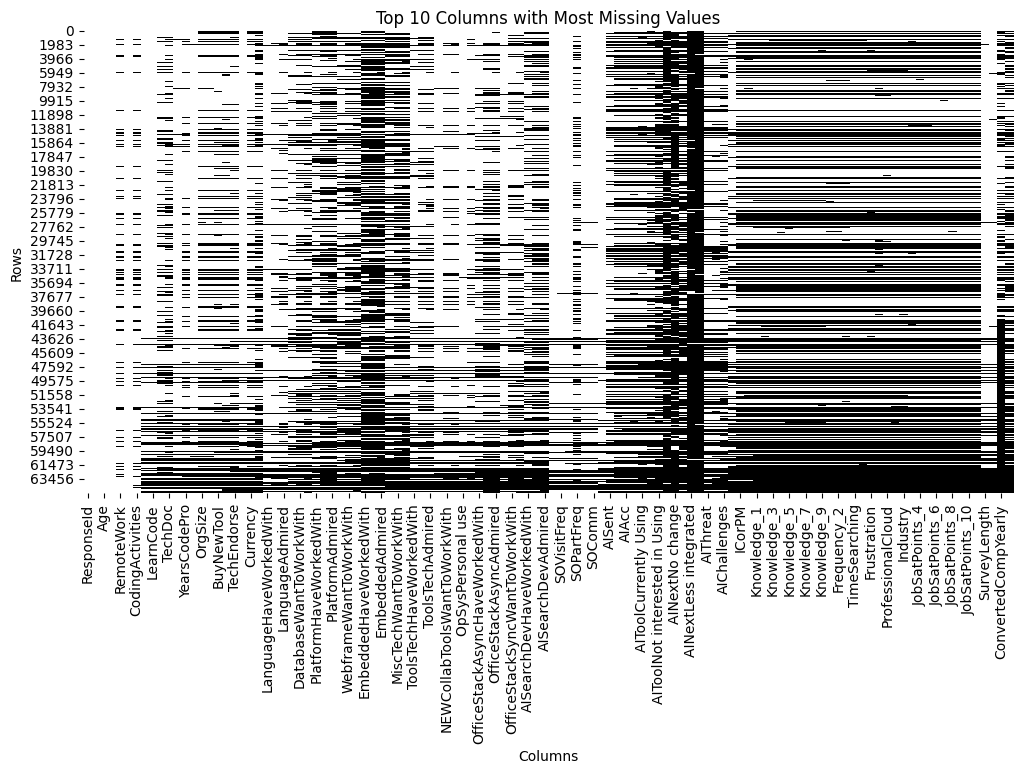

In [69]:
#top10_cols =df.isnull().sum().sort_values(ascending=False).head(30).index
#top10_rows = df.isnull().sum(axis=1).sort_values(ascending=False).head(30).index
#df_top10 = df.loc[top10_rows, top10_cols]

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='gist_yarg')


plt.title("Top 10 Columns with Most Missing Values")
plt.xlabel("Columns")
plt.xticks(rotation=90)
plt.ylabel("Rows")
plt.yticks(rotation=0)
plt.show()

##### Count the number of missing rows for a specific column (e.g., `Employment`).


In [70]:
print(df.columns, df.head(10))


Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)    ResponseId                                         MainBranch  \
0           1                     I am a developer by profession   
1           2                     I am a developer by profession   
2           3                     I am a developer by profession   
3           4                              I am learning to code   
4           5                     I am a developer by profession   
5           6                        I code primarily as a hobby   
6           7  I am not primarily a developer, but I write co...   
7           8                              I am learning to code   
8 

In [71]:
missing_values = df.isnull().sum()

print(missing_values)


ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64


### Imputing Missing Values
##### Identify the most frequent (majority) value in a specific column (e.g., `Employment`).

In [72]:
RemoteWork = df['RemoteWork'].mode()[0]
print("Most frequent value in RemoteWork column:", RemoteWork)

Most frequent value in RemoteWork column: Hybrid (some remote, some in-person)


##### Impute missing values in the `Employment` column with the most frequent value.


In [73]:
most_frequent_employment = df['Employment'].mode()[0]
df['Employment'] = df['Employment'].fillna(most_frequent_employment)
print("Remaining missing values in Employment:", df['Employment'].isnull().sum())

Remaining missing values in Employment: 0


Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).

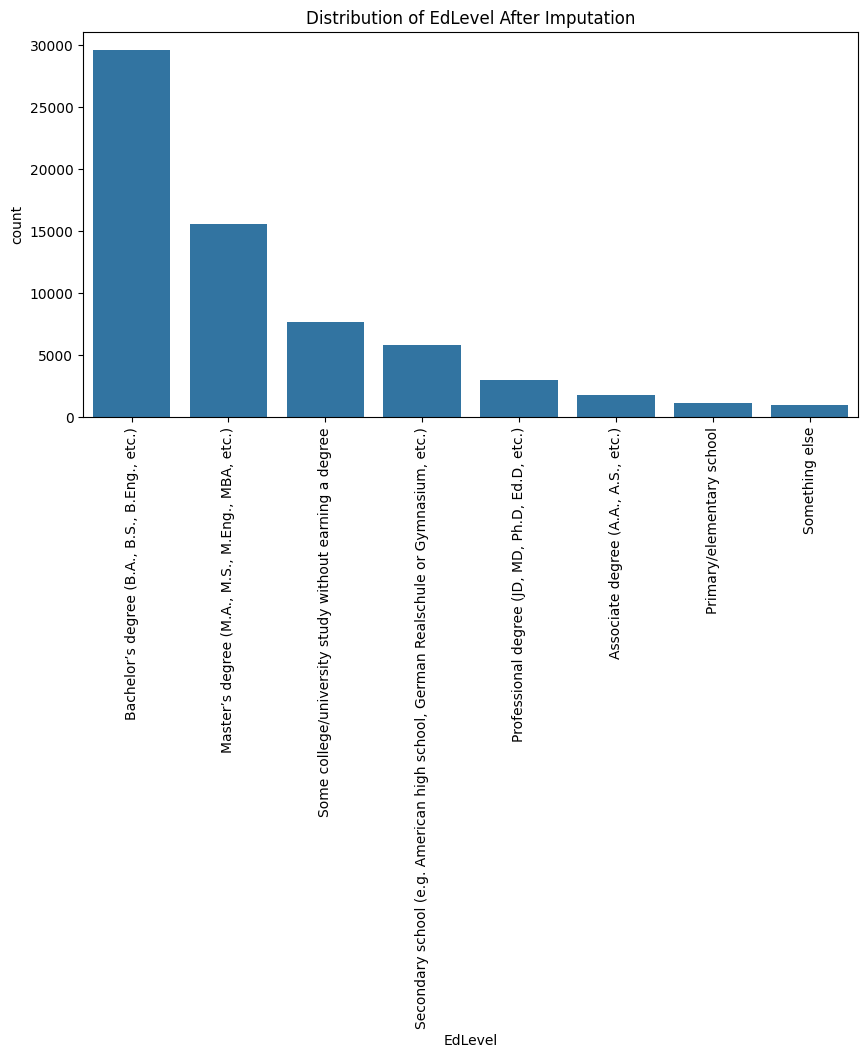

In [ ]:

# Step 1: Impute missing values with mode
mode_value = df_copy["EdLevel"].mode()[0]
df_copy.fillna({"EdLevel": mode_value}, inplace=True)

# Step 2: Plot distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df_copy, x="EdLevel", order=df_copy["EdLevel"].value_counts().index)

plt.title("Distribution of EdLevel After Imputation")
plt.xticks(rotation=90)
plt.show()